## Exercise 4 - Hierarchical models and testing
**Group memers:** Andrea Raachou, Preston, Jenny Laberg Nilsson   
**Course:** BERN02   
**Semester:** Autumn 2026   

In [32]:
import pandas as pd
import numpy as np
import bambi as bmb # BAyesian Model-Building Interface in Python
import arviz as az # essentail dependency
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pooch import retrieve # Download files over http

### Import Data

In [63]:
# Read data, put in pandas dataframe
url = "https://osf.io/download/qsb3f"
path = retrieve(url=url, known_hash=None)
data = pd.read_csv(path, encoding="latin1", sep = ';')
print(data.head())

               Source        AuthorName  Experiment  Year        Group  \
0  Goldstein.2008.Ex1  Goldstein et al.           1  2008      Control   
1  Goldstein.2008.Ex1  Goldstein et al.           1  2008  Social Norm   
2  Goldstein.2008.Ex1  Goldstein et al.           1  2008      Control   
3  Goldstein.2008.Ex1  Goldstein et al.           1  2008  Social Norm   
4  Goldstein.2008.Ex2  Goldstein et al.           2  2008      Control   

  Towel.Reuse  Count  
0         Yes     74  
1         Yes     98  
2          No    137  
3          No    124  
4         Yes    103  


### Data wrangling
Copied from exercise instructions

In [34]:
count = data.iloc[:, -1] # get the last column with numbers or yes/no

# count has the number of yes and no for control and social norm groups
control_yes = count[::4].to_numpy() # every 4th starting from 0 - control group + yes
control_no = count[2::4].to_numpy() # every 4th starting from 2 - control group + no
control_total = np.array([y + n for y, n in zip(control_yes, control_no)])

social_yes = count[1::4].to_numpy() # every 4th starting from 1 - social norm group + yes
social_no = count[3::4].to_numpy() # every 4th starting from 3 - social norm group + no
social_total = np.array([y + n for y, n in zip(social_yes, social_no)])

study = np.arange(1,len(control_yes)+1) # 7 different studies
control_data = pd.DataFrame({"reuse": control_yes, "total": control_total, "group": "control", "study": study})
social_data = pd.DataFrame({ "reuse": social_yes, "total": social_total, "group": "social", "study": study})

combined_data = pd.concat([control_data, social_data], ignore_index=True)

# Convert data types - important for bambi that they are correctly set. an give errors otherwise
combined_data['reuse'] = combined_data['reuse'].astype(int)
combined_data['total'] = combined_data['total'].astype(int)
combined_data['group'] = combined_data['group'].astype('category')
combined_data['study'] = combined_data['study'].astype('category')

print(combined_data.head())

   reuse  total    group study
0     74    211  control     1
1    103    277  control     2
2     77    135  control     3
3     82    187  control     4
4     21     25  control     5


### Theory
#### Introduction
This study analyzes data from a collection of randomized controlled trials evaluating the effectiveness of *descriptive social norms* on hotel guests' towel reuse behavior (Scheibehenne et al., 2016). Descriptive social norm messages inform guests about the observed majority behavior of previous occupants (e.g., "75% of guests who stayed in this room reused their towels at least once during their stay."). In addition, a standard control message that doesn't include the behaviour of previous occupants is used (e.g., "You can show your respect for nature by reusing your towels")

The response variable represents aggregated count data (number of towelse reused out of total opportunities per condition), which follows a Binomial distribution.

#### Hypothesis testing
To evaluate the effectiveness of the descriptive social norm intervention relative to standard control messaging, we formulate hypotheses directly targeting the fixed-effect slope parameter ($\beta_1$), which represents the log-odds ratio of towel reuse under the intervention:
* Null Hypothesis ($H_0$): $\beta_1 = 0$: The descriptive social norm message has no effect on the log-odds (probability) of towel reuse.
* Alternative Hypothesis ($H_1$): $\beta_1 \neq 0$: The descriptive social norm message alters the log-odds of towel reuse relative to the standard control message.

#### Hierarchical Model Structure
We employ a Hierachical Binomial Logistic Model that has a group specific intercept for each study (random effect) and use a shared slope (fixed effect). This means that the effect is overall the same (difference between no social norm and with social norm) but that the studies may differ in other ways - like choice of hotel or area, or time of the study.

Model to use (written using two different notations): 
$$
\begin{aligned}
y_{ij} &= \beta_0 + u_{j} + \beta_1 x_{ij} + \epsilon_{ij} \\
Y_{ij} |x &\sim Binomial(\beta_0 + u_{j} + \beta_1 x_{ij}, \sigma) 
\end{aligned}
$$
where $u_{j}$ represents the random effect for each study, $\beta_0 + u_{j}$ represents the baseline intercept for each study and $\beta_1$ represents the fixed effected slope. 

#### Prior Specifications
In a Bayesian framework, we assign prior distributions to all unobserved parameters ($\beta_0, \beta_1$, and $\tau$). They are specified using the following distributions, with hyperparameters $\mu_{\beta_0}$, $\sigma_{\beta_0}$, $\mu_{\beta_1}$, $\sigma_{\beta_1}$, and $\sigma_\tau$:

$$
\begin{aligned}
\beta_0 &\sim N(\mu_{\beta_0}, \sigma_{\beta_0}) \\
\beta_1 &\sim N(\mu_{\beta_1}, \sigma_{\beta_1}) \\
\tau &\sim \Gamma(\sigma_\tau) 
\end{aligned}
$$

By default, `bambi` automatically computes weakly informative hyperparameters scaled to the data to aid MCMC convergence. We use the given hyperparameters.

### Model set-up

In [35]:
# Model with random interecept for each study and no group (null hypothesis)
m1 = bmb.Model("p(reuse, total) ~ 1 + (1|study)", combined_data, family="binomial") 
print(m1)
print("")

# Model with random interecept for each study and group (control/social) as intercept
m2 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial") 
print(m2)

       Formula: p(reuse, total) ~ 1 + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))

       Formula: p(reuse, total) ~ 1 + group + (1|study)
        Family: binomial
          Link: p = logit
  Observations: 14
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 1.5)
            group ~ Normal(mu: 0.0, sigma: 1.0)
        
        Group-level effects
            1|study ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5495))


### Fit the model

In [36]:
idata1 = m1.fit() 
idata2 = m2.fit() # Initial model, nothing changed by us

#idata2 = m2.fit(draws = 1000, tune=1000, target_accept=1, seed = 42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, 1|study_sigma, 1|study_offset]


/Users/labergnilsson/Documents/E3_hierarchical_models_and_testing/.venv/lib/python3.13/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 153 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/labergnilsson/Documents/E3_hierarchical_models_and_testing/.venv/lib/python3.13/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.


### Evaluate priors and improve model fit

In [37]:
# There is a large numer of divergences (28) - which indicates a problem with the underlying model (according to bambi website)

# Look at the prior predictive distribution, see plots below
idata_prior = m2.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
print(idata_prior)

Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:            (chain: 1, draw: 500, __obs__: 14, study__factor_dim: 7,
│                               group_dim: 1)
│       Coordinates:
│         * chain              (chain) int64 8B 0
│         * draw               (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│         * __obs__            (__obs__) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
│         * study__factor_dim  (study__factor_dim) <U1 28B '1' '2' '3' '4' '5' '6' '7'
│         * group_dim          (group_dim) <U6 24B 'social'
│       Data variables:
│           p                  (chain, draw, __obs__) float64 56kB 0.01207 ... 0.8116
│           Intercept          (chain, draw) float64 4kB -0.4285 0.4341 ... 2.21 0.6644
│           1|study            (chain, draw, study__factor_dim) float64 28kB -3.789 ....
│           group              (chain, draw, group_dim) float64 4kB 0.3733 ... 1.46
│           1|study_sigma      (chain, draw) float64 4kB 3.5

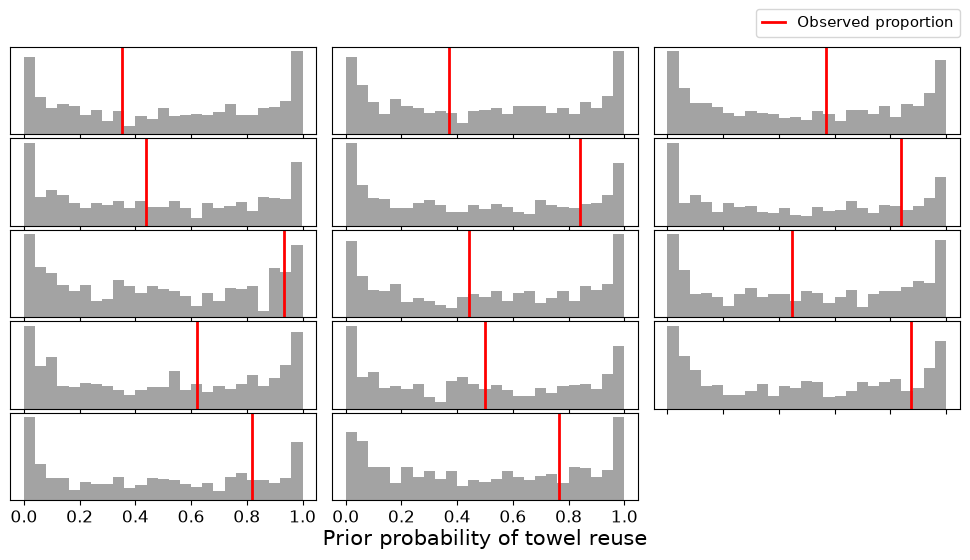

In [38]:
def plot_prior_predictive(df, prior):
    total = df["total"].values
    reuse = df["reuse"].values
    fig, axes = plt.subplots(5, 3, figsize=(10, 6), sharex="col")

    for idx, ax in enumerate(axes.ravel()):
        # Stop after the 14 observations
        if idx >= len(df):
            ax.axis("off")
            continue

        pps = prior.sel({"__obs__": idx})
        observed_proportion = reuse[idx] / total[idx]
        ax.hist(pps, bins=25, color="#a3a3a3")
        ax.axvline(observed_proportion, color="red", lw=2)
        ax.set_yticks([])
        ax.tick_params(labelsize=12)

    fig.subplots_adjust(
        left=0.025,
        right=0.975,
        hspace=0.05,
        wspace=0.05,
        bottom=0.125)

    fig.legend(
        handles=[
            Line2D(
                [0], [0],
                label="Observed proportion",
                color="red",
                linewidth=2)],
        handlelength=1.5,
        handletextpad=0.8,
        borderaxespad=0,
        frameon=True,
        fontsize=11,
        bbox_to_anchor=(0.975, 0.92),
        loc="right")

    fig.text(
        0.5,
        0.05,
        "Prior probability of towel reuse",
        fontsize=15,
        ha="center",
        va="baseline")

plot_prior_predictive(combined_data, prior)

These plots show that the initial priors are too wide. To address this, we refine the prior specifications by reducing the ($\sigma$) parameter to constrain the model.

In [39]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), 
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=2)) 
}
m3 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
m3

idata3 = m3.fit()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/labergnilsson/Documents/E3_hierarchical_models_and_testing/.venv/lib/python3.13/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


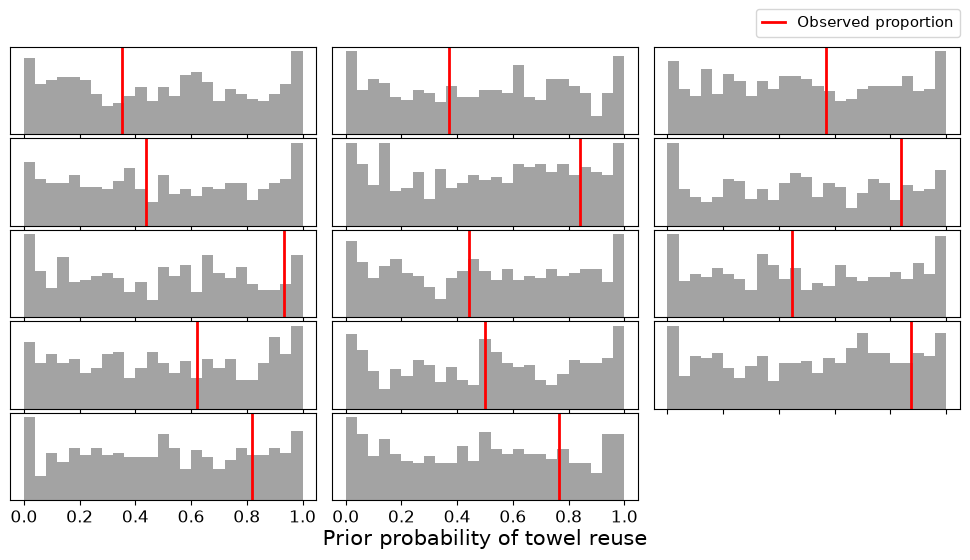

In [40]:
# Validating priors
m3.build()
idata_prior = m3.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

Slightly better but still not what we want?

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/labergnilsson/Documents/E3_hierarchical_models_and_testing/.venv/lib/python3.13/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
There were 289 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [1|study_offset, 1|study_sigma, Intercept, group, p(reuse, total)]


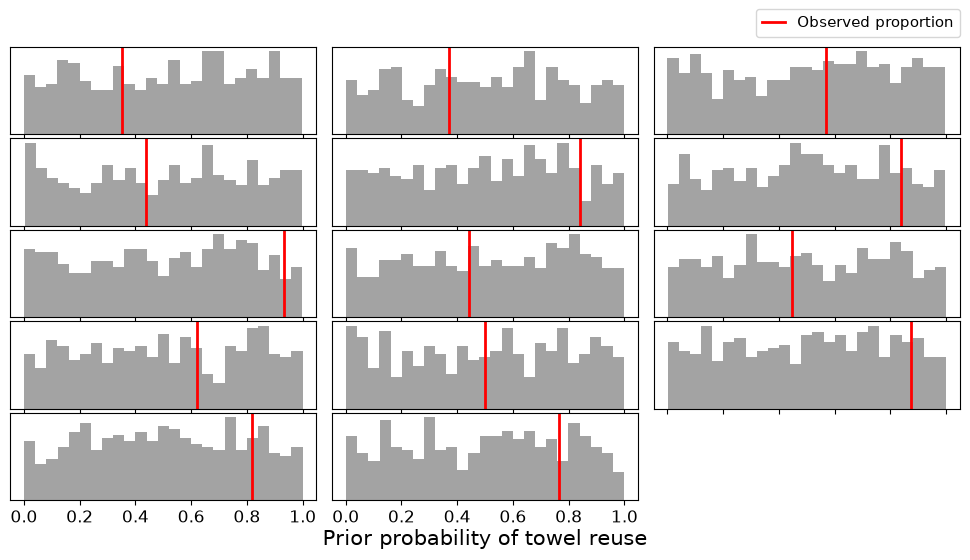

In [51]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1), 
    "1|study": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1.5)) # Changed sigma from 2 to 1.
}
m3 = bmb.Model("p(reuse, total) ~ 1 + group + (1|study)", combined_data, family="binomial", priors=priors)
m3

idata3 = m3.fit()

m3.build()
idata_prior = m3.prior_predictive()
prior = az.extract(idata_prior, group="prior")["p"]
plot_prior_predictive(combined_data, prior)

Lowering the hyper-prior scale gives us a better prior predictive distribution. On the probability scale, the simulated outcomes spread evenly between 0 and 1. This keeps the priors weakly informative while avoiding extreme values near 0% or 100%. Importantly, all observed study proportions (red lines) fall well within these predictions.

### Compare predictions

In [52]:
idata3 = m3.fit(target_accept = 0.95) # update the model

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, group, 1|study_sigma, 1|study_offset]


/Users/labergnilsson/Documents/E3_hierarchical_models_and_testing/.venv/lib/python3.13/site-packages/rich/live.py:2
60: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


Here, we generate MCMC trace plots (az.plot_trace) to visually assess chain convergence and mixing across our model parameters ($\beta_0$, $\beta_1$, $u_j$, and $\tau$).

Data variables:
    Intercept      (chain, draw) float64 32kB 0.06653 0.4514 ... 0.3546 0.4199
    group          (chain, draw, group_dim) float64 32kB 0.2315 ... 0.2636
    1|study_sigma  (chain, draw) float64 32kB 1.342 0.7908 ... 0.6556 0.6867
    1|study        (chain, draw, study__factor_dim) float64 224kB -0.6537 ......


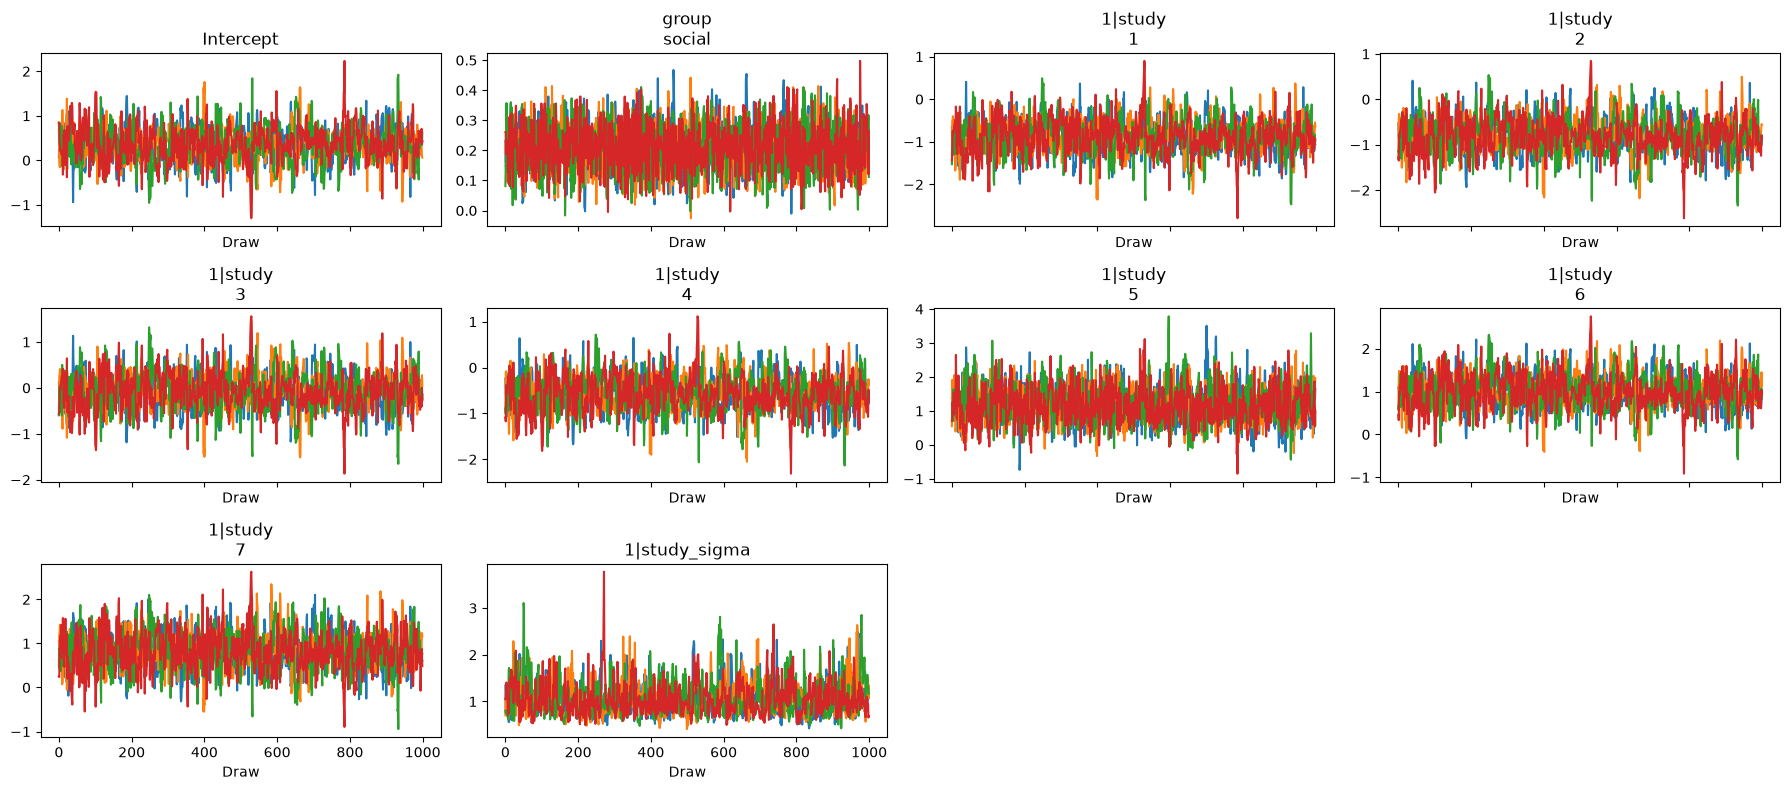

In [47]:
var_names = ["Intercept", "group", "1|study", "1|study_sigma"]
az.plot_trace(idata3, var_names=var_names)
plt.gcf().set_size_inches(18, 8)
plt.tight_layout()

"""
# Find all axes and make their y-axis limits the same
all_axes = plt.gcf().axes

y_limits = [ax.get_ylim() for ax in all_axes]
y_min = min(y[0] for y in y_limits)
y_max = max(y[1] for y in y_limits)

for ax in all_axes:
    ax.set_ylim(y_min, y_max)

"""
print(idata3.posterior.data_vars)


Visual inspection of the MCMC trace plots confirms strong sampling performance and convergence across all four chains.

### Compare predictors
We now make a summary of the posterior distributions for the primary model parameters using the posterior mean and 90% probabilty intervals.

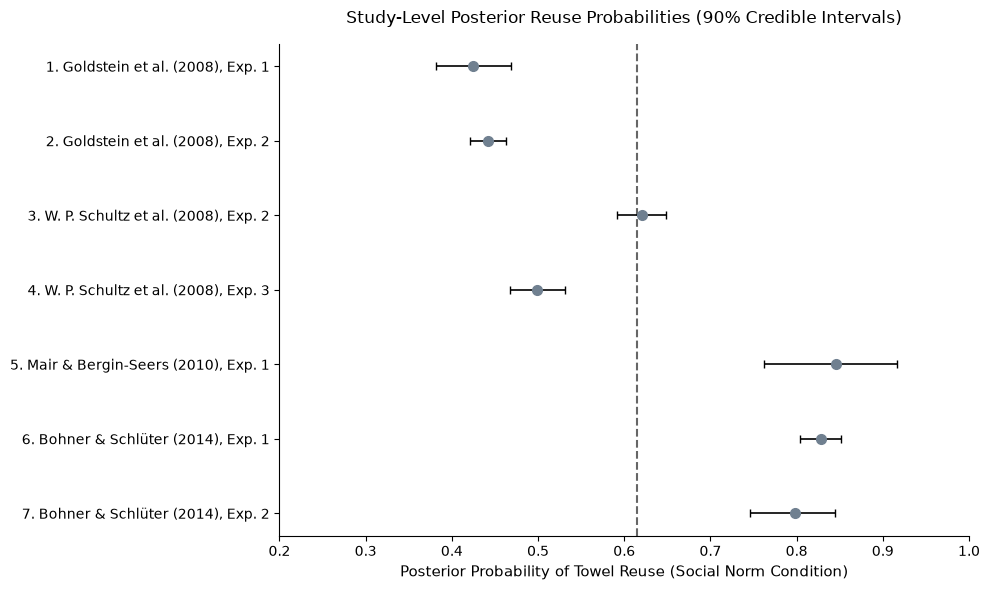

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define study labels matching your 7 studies
study_labels = [
    "1. Goldstein et al. (2008), Exp. 1",
    "2. Goldstein et al. (2008), Exp. 2",
    "3. W. P. Schultz et al. (2008), Exp. 2",
    "4. W. P. Schultz et al. (2008), Exp. 3",
    "5. Mair & Bergin-Seers (2010), Exp. 1",
    "6. Bohner & Schlüter (2014), Exp. 1",
    "7. Bohner & Schlüter (2014), Exp. 2"
]

# 2. Extract study-specific posterior predictions (e.g., probabilities for Social Norm condition)
# Assuming observations 0..6 = Control, 7..13 = Social Norm (adjust indices to match your data structure)
social_norm_idx = np.arange(7, 14) 
p_samples = idata3.posterior["p"].stack(sample=("chain", "draw")).values

study_means = p_samples[social_norm_idx, :].mean(axis=1)
study_lowers = np.quantile(p_samples[social_norm_idx, :], 0.05, axis=1)
study_uppers = np.quantile(p_samples[social_norm_idx, :], 0.95, axis=1)

# 3. Create Forest Plot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(study_labels))[::-1] # Reverse order to plot Study 1 at top

# Vertical reference line for overall sample mean
overall_mean = p_samples.mean()
ax.axvline(x=overall_mean, color="black", linestyle="--", alpha=0.6, label="Grand Mean")

# Error bars for study estimates
ax.errorbar(
    study_means,
    y_pos,
    xerr=[study_means - study_lowers, study_uppers - study_means],
    fmt="o",
    color="slategray",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    markersize=7
)

# Customize Axis & Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(study_labels, fontsize=10, fontweight="medium")
ax.set_xlabel("Posterior Probability of Towel Reuse (Social Norm Condition)", fontsize=11)
ax.set_xlim(0.2, 1.0)

# Clean styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title("Study-Level Posterior Reuse Probabilities (90% Credible Intervals)", fontsize=12, pad=15)

plt.tight_layout()
plt.show()

In [57]:
summary = az.summary(idata3, ci_prob=0.90, kind="stats")
print(summary)
combined_data

                 mean     sd eti90_lb eti90_ub
Intercept        0.36   0.39    -0.28     0.99
group[social]    0.21  0.078    0.083     0.34
1|study_sigma       1   0.34     0.63      1.7
1|study[1]      -0.88    0.4     -1.5    -0.22
1|study[2]       -0.8   0.39     -1.4    -0.16
1|study[3]     -0.077   0.39    -0.71     0.56
1|study[4]      -0.57   0.39     -1.2    0.064
1|study[5]        1.2   0.52     0.37      2.1
1|study[6]          1   0.39     0.37      1.6
1|study[7]       0.81   0.42     0.15      1.5
p[0]             0.37  0.025     0.33     0.42
p[1]             0.39  0.019     0.36     0.42
p[2]             0.57  0.024     0.53     0.61
p[3]             0.45  0.023     0.41     0.49
p[4]             0.82  0.055     0.72      0.9
p[5]              0.8  0.019     0.76     0.83
p[6]             0.76  0.036      0.7     0.82
p[7]             0.42  0.026     0.38     0.47
p[8]             0.44  0.013     0.42     0.46
p[9]             0.62  0.018     0.59     0.65
p[10]        

,reuse,total,group,study
0,74,211,control,1
1,103,277,control,2
2,77,135,control,3
3,82,187,control,4
4,21,25,control,5
5,123,147,control,6
6,28,30,control,7
7,98,222,social,1
8,587,1318,social,2
9,406,655,social,3


### Discussion
* Evaluate the tree diagram, make it more descriptive 
* Test the hypothesis using Bayesian inference. Evaluate this: group[social]    0.21  0.078    0.083     0.34    

Expressed as an odds ratio, exposure to descriptive social norms increases the odds of hotel guest towel reuse by approximately $23\%$ ($e^{0.21} \approx 1.23$).Because the entire 90% Equal-Tailed Interval ($[0.083, 0.34]$) sits strictly above zero, $100\%$ of the posterior samples indicate a positive effect, allowing us to rule out $H_0$ at the 90% credibility level. 

* Overall analysis of the model results, discuss together on Monday?

### References
Capretto, T., Camilleri, A. R., & Bambi Contributors. (n.d.). Hierarchical Binomial Logistic Regression in Bambi. Bambi Documentation. Retrieved from https://bambinos.github.io/bambi/notebooks/hierarchical_binomial_bambi.html